# Week 4 Assignment
## Smart Travel Planner

**Objective:** Train an ML classifier to correct classify a user's specified trip.

**Dataset:** LLM-created dataset, `destinations.csv` (203 rows, 10 columns)

**Target:** `label`, 6 values (Adventure, Budget, Culture, Family, Luxury, Relaxation)  

**Split:** 60 / 20 / 20 stratified (train / val / test), `random_state=42`

## Data handling

### Load data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '{:.0f}'.format(x) if int(x) == x else '{:.3f}'.format(x))
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
df = pd.read_csv("destinations_1000.csv")
df_orig = df.copy()  # backup copy

### Inspect data

In [ ]:
df.head()

,city,country,hiking_score,beach_score,cultural_sites_score,nightlife_score,family_friendly_score,luxury_infrastructure_score,avg_accom_cost,avg_daily_expense,safety_score,remoteness_score,label
0,Kathmandu,Nepal,9,1,7,3,3,2,15,12,5,7,Adventure
1,Queenstown,New Zealand,9,3,3,6,5,7,130,60,9,7,Adventure
2,Patagonia,Argentina,10,1,2,1,2,3,60,35,7,9,Adventure
3,Interlaken,Switzerland,9,2,3,4,5,7,160,55,9,5,Adventure
4,Huaraz,Peru,10,1,3,2,2,1,20,12,5,9,Adventure


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   city                         1000 non-null   object
 1   country                      1000 non-null   object
 2   hiking_score                 1000 non-null   int64 
 3   beach_score                  1000 non-null   int64 
 4   cultural_sites_score         1000 non-null   int64 
 5   nightlife_score              1000 non-null   int64 
 6   family_friendly_score        1000 non-null   int64 
 7   luxury_infrastructure_score  1000 non-null   int64 
 8   avg_accom_cost               1000 non-null   int64 
 9   avg_daily_expense            1000 non-null   int64 
 10  safety_score                 1000 non-null   int64 
 11  remoteness_score             1000 non-null   int64 
 12  label                        1000 non-null   object
dtypes: int64(10), object(3)
memory usa

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
hiking_score,1000,4.292,1.959,1,3,4,5,10
beach_score,1000,3.795,2.801,1,1,3,7,10
cultural_sites_score,1000,4.469,2.308,1,3,4,6,10
nightlife_score,1000,3.259,1.652,1,2,3,4,9
family_friendly_score,1000,4.409,1.708,1,3,4,5,10
luxury_infrastructure_score,1000,4.411,2.186,1,3,4,5,10
avg_accom_cost,1000,77.556,94.412,6,20,55,90,900
avg_daily_expense,1000,29.208,23.272,3,10,25,40,160
safety_score,1000,7.085,1.560,3,6,7,8,9
remoteness_score,1000,5.825,1.977,1,4,6,7,10


Notable outliers in the data for Seychelles:
* avg_accom_cost = 900 (median = 70)
* avg_daily_expense = 160 (median = 30)

In [ ]:
print(f"Destinations with max accom cost:\n" \
      f"{df[df['avg_accom_cost'] == 900][['city', 'country']]}\n")
print(f"Destinations with max daily expense:\n" \
      f"{df[df['avg_daily_expense'] == 160][['city', 'country']]}")

Destinations with max accom cost:
               city     country
998  Fregate Island  Seychelles

Destinations with max daily expense:
               city     country
998  Fregate Island  Seychelles


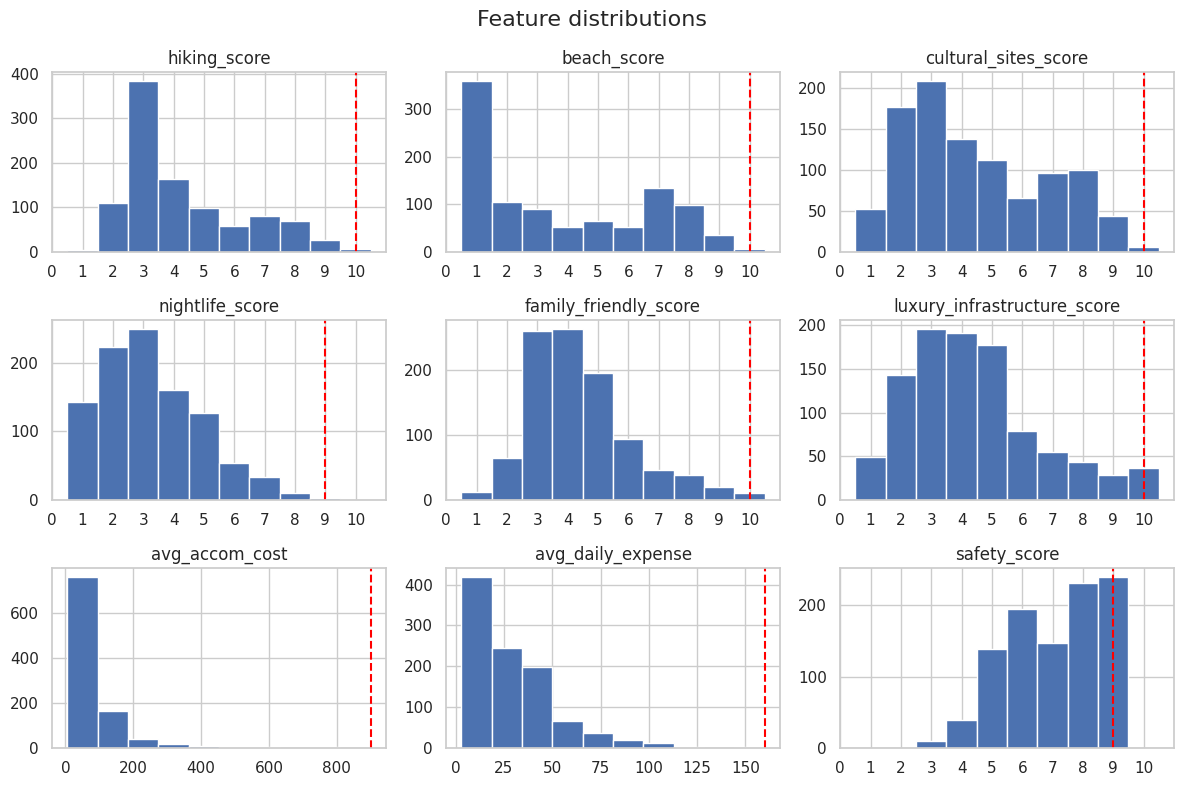

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
for ax, col in zip(axes.flatten(), df.select_dtypes(include='number')):
  if col != 'avg_accom_cost' and col != 'avg_daily_expense':
    ax.hist(df[[col]], bins=np.arange(0.5,11.5,1))
    ax.set_xticks(range(0,11))
  else:
    ax.hist(df[[col]], bins=10)
  ax.set_title(col)
  ax.axvline(df[col].max(), color="red", linestyle="--")

plt.suptitle("Feature distributions", fontsize=16)
plt.tight_layout()
plt.show()

**Label balance**

Fairly balanced, Family and Luxury are the two least prevalent labels.

label
Adventure    23 %
Culture      20 %
Budget       16 %
Relaxation   16 %
Family       14 %
Luxury       10 %


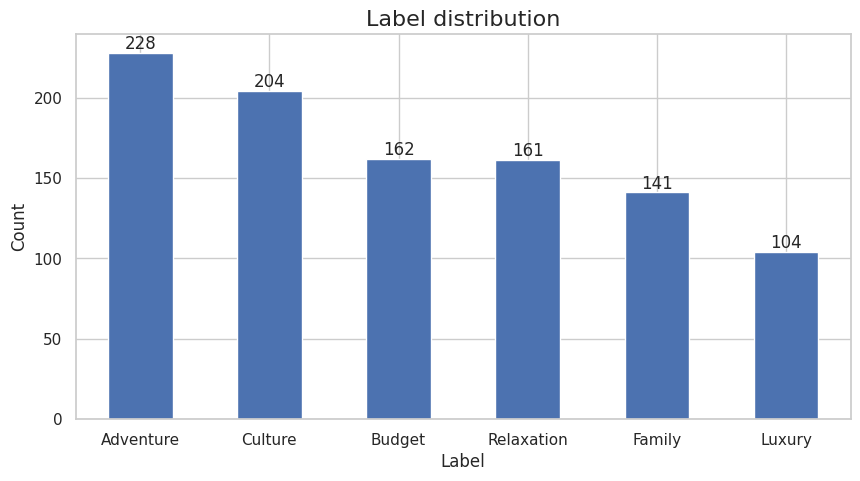

In [ ]:
print("label")
for name, count in df['label'].value_counts(normalize=True).items():
  print(f"{name:<12} {round(count * 100)} %")

ax = df['label'].value_counts().plot(kind='bar')
for patch in ax.patches:
  height = round(patch.get_height())
  if height > 0:
    ax.annotate(f'{height}', (patch.get_x() + patch.get_width() / 2, height), ha='center', va='bottom')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_title('Label distribution', fontsize=16)
plt.xticks(ha='center', rotation=0)
plt.show()

In [ ]:
df['city'].nunique(), df['country'].nunique(), df.shape
# => No city duplicates (1000 unique values, over 145 countries)

(1000, 145, (1000, 13))

### Split data

In [ ]:
X = df.copy()
y = X['label']
# Remove city and country from the X data
X = X.drop(columns=['label', 'city', 'country'])

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'\nTrain: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')


Train: (600, 10) | Val: (200, 10) | Test: (200, 10)


In [ ]:
print('=' * 52)
print(' Split ("Family")  N   Total  Percent')
print('=' * 52)
for split_name, y_s in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    n       = y_s[y_s == 'Family'].count()
    total   = y_s.count()
    pct     = n / total * 100
    print(f'  {split_name:<12} {n:>6} {total:>5} {pct:>6.1f}%')
print('=' * 52)
print('Stratification confirmed: Same proportion of values for least frequent label.')

 Split ("Family")  N   Total  Percent
  Train            85   600   14.2%
  Val              28   200   14.0%
  Test             28   200   14.0%
Stratification confirmed: Same proportion of values for least frequent label.


### Data analysis

**Cross-correlation**
* Cost features are strongly correlated with luxury infrastructure
* Beach is negatively correlated with hiking and cultural sites
* Nightlife is strongly negatively correlated with remoteness, mid-negative with beach and mid-positive with family and luxury
* Safety is strongly correlated with cost, luxury and family
* Remoteness is correlated with hiking, strongly negatively correlated with nightlife and family

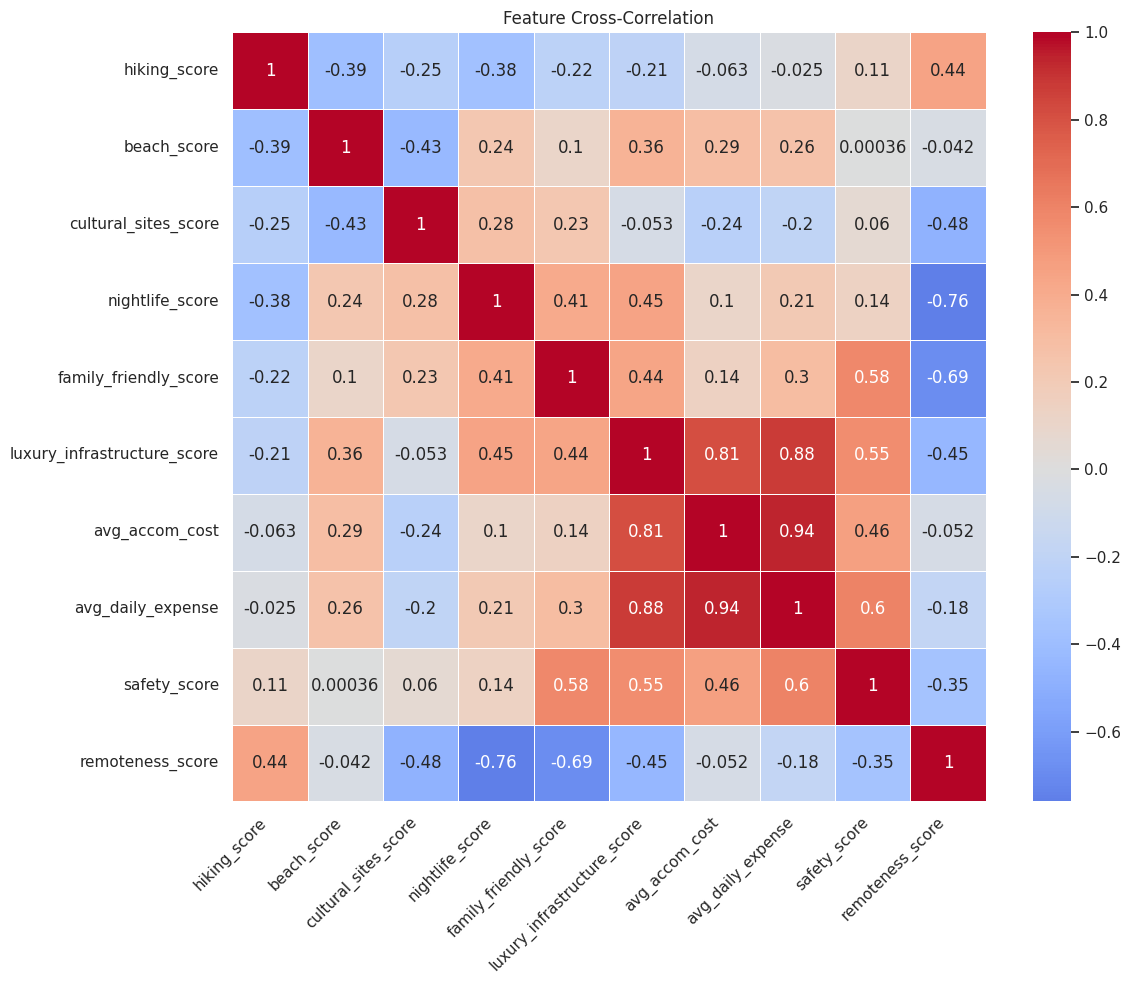

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_train.corr(), annot=True, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Cross-Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

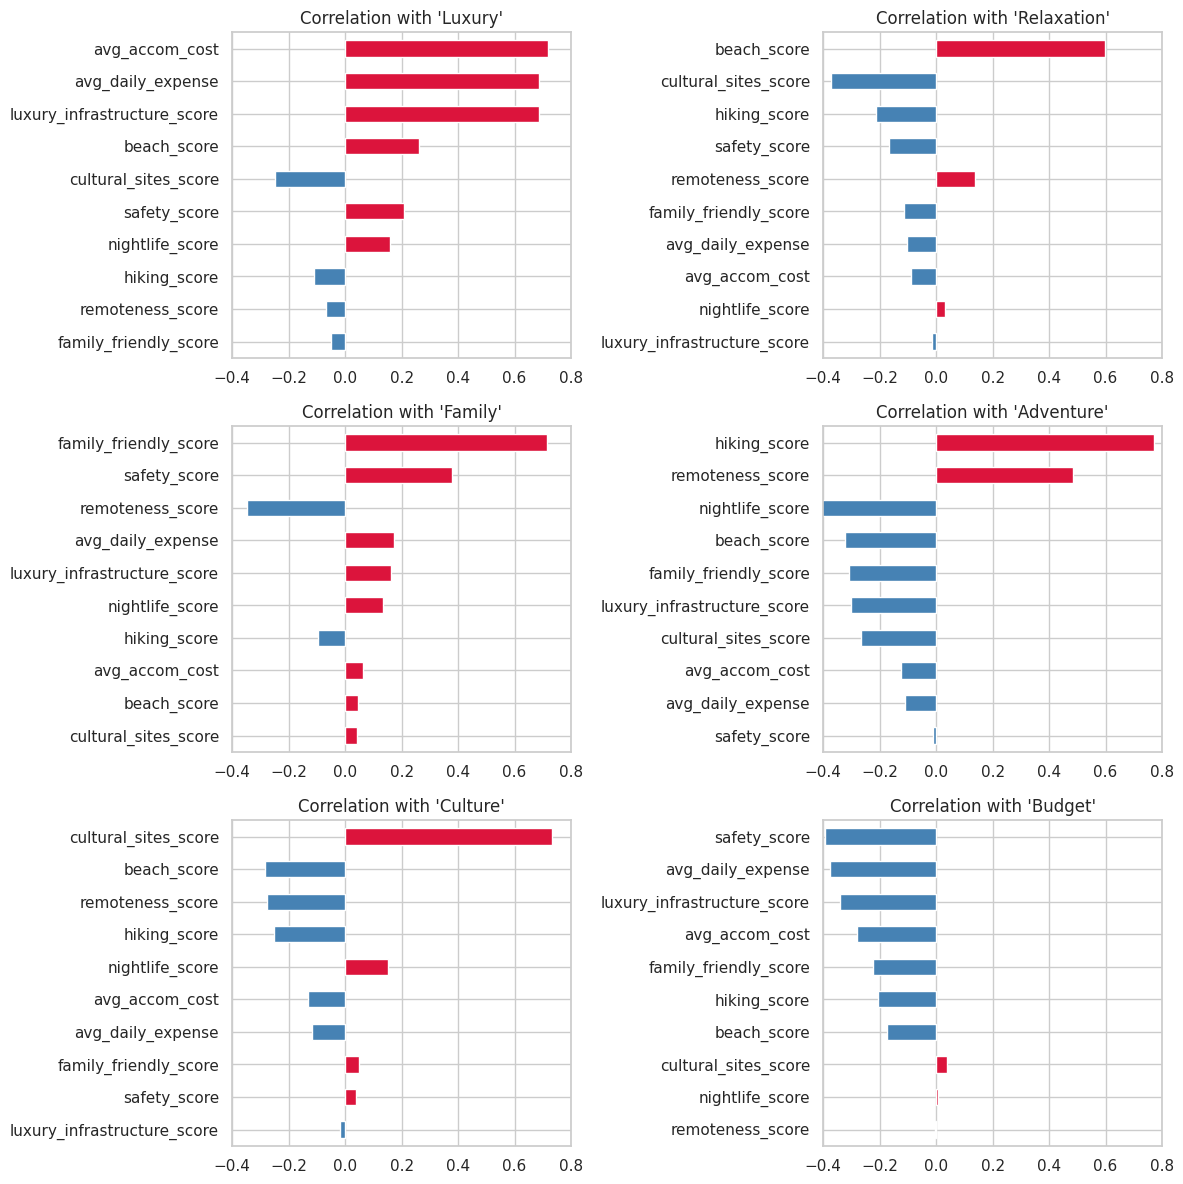

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
for ax, label_value in zip(axes.flatten(), y_train.unique()):
    correlations = pd.Series({
        col: np.corrcoef(X_train[col], (y_train == label_value).astype(int))[0, 1]
            for col in X_train.columns
    }).sort_values(key=abs)

    colors = correlations.apply(lambda x: "crimson" if x > 0 else "steelblue")
    correlations.plot.barh(ax=ax, color=colors)
    ax.set_title(f"Correlation with '{label_value}'")
    ax.set_xlim(-0.4, 0.8)

plt.tight_layout()
plt.show()

## Model training

We'll evaluate models on **overall accuracy** - total proportion of correct answers - as we want to correctly distribute the different destinations across the possible labels.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, accuracy_score,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
)

In [ ]:
label_names = y_train.unique()

array(['Luxury', 'Relaxation', 'Family', 'Adventure', 'Culture', 'Budget'],
      dtype=object)

### Baseline: Logistic Regression

In [157]:
# Training
lr_pipeline = Pipeline([
  ('scaler', StandardScaler()),
  ('model', LogisticRegression(
      max_iter=100,         # default value = 100 is fine
      random_state=42))
])
lr_pipeline.fit(X_train, y_train)
y_lr = lr_pipeline.predict(X_train)
print(classification_report(y_train, y_lr))

              precision    recall  f1-score   support

   Adventure       0.93      0.94      0.93       137
      Budget       0.88      0.88      0.88        97
     Culture       0.94      0.93      0.94       122
      Family       0.95      0.92      0.93        85
      Luxury       0.93      0.92      0.93        62
  Relaxation       0.86      0.89      0.87        97

    accuracy                           0.92       600
   macro avg       0.92      0.91      0.91       600
weighted avg       0.92      0.92      0.92       600



In [158]:
# Label values for all pipelines (alphabetically sorted list)
print(lr_pipeline.named_steps['model'].classes_)
# Define label shorthand
label_shd = ['Adv', 'Bud', 'Cul', 'Fam', 'Lux', 'Rlx']
print(label_shd)

['Adventure' 'Budget' 'Culture' 'Family' 'Luxury' 'Relaxation']
['Adv', 'Bud', 'Cul', 'Fam', 'Lux', 'Rlx']


In [159]:
# Try on validation data
y_lr = lr_pipeline.predict(X_val)
print(classification_report(y_val, y_lr))

              precision    recall  f1-score   support

   Adventure       0.93      0.96      0.95        45
      Budget       0.84      0.82      0.83        33
     Culture       0.90      0.90      0.90        41
      Family       0.93      0.93      0.93        28
      Luxury       0.87      0.95      0.91        21
  Relaxation       0.87      0.81      0.84        32

    accuracy                           0.90       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.90      0.89       200



Baseline model seems pretty good, accuracy = 90 %, macro/weighted averages are around 0.89 for both precision and recall.

Not much of a drop from training data metrics.

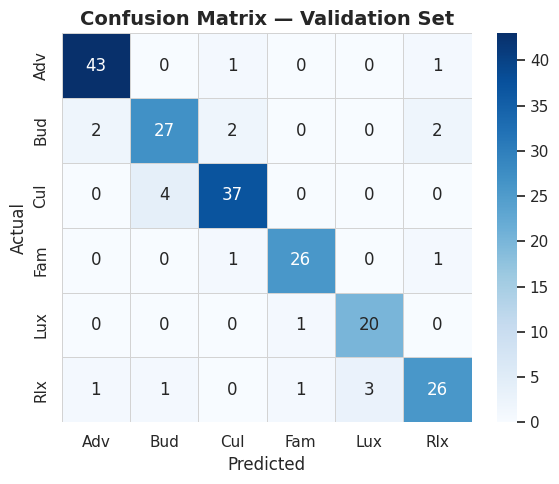

In [160]:
cm = confusion_matrix(y_val, y_lr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_shd,
    yticklabels=label_shd,
    linewidths=0.5, linecolor='lightgray',
    ax=ax,
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature importances

In [ ]:
lr_pipeline.feature_names_in_

array(['hiking_score', 'beach_score', 'cultural_sites_score',
       'nightlife_score', 'family_friendly_score',
       'luxury_infrastructure_score', 'avg_accom_cost',
       'avg_daily_expense', 'safety_score', 'remoteness_score'],
      dtype=object)

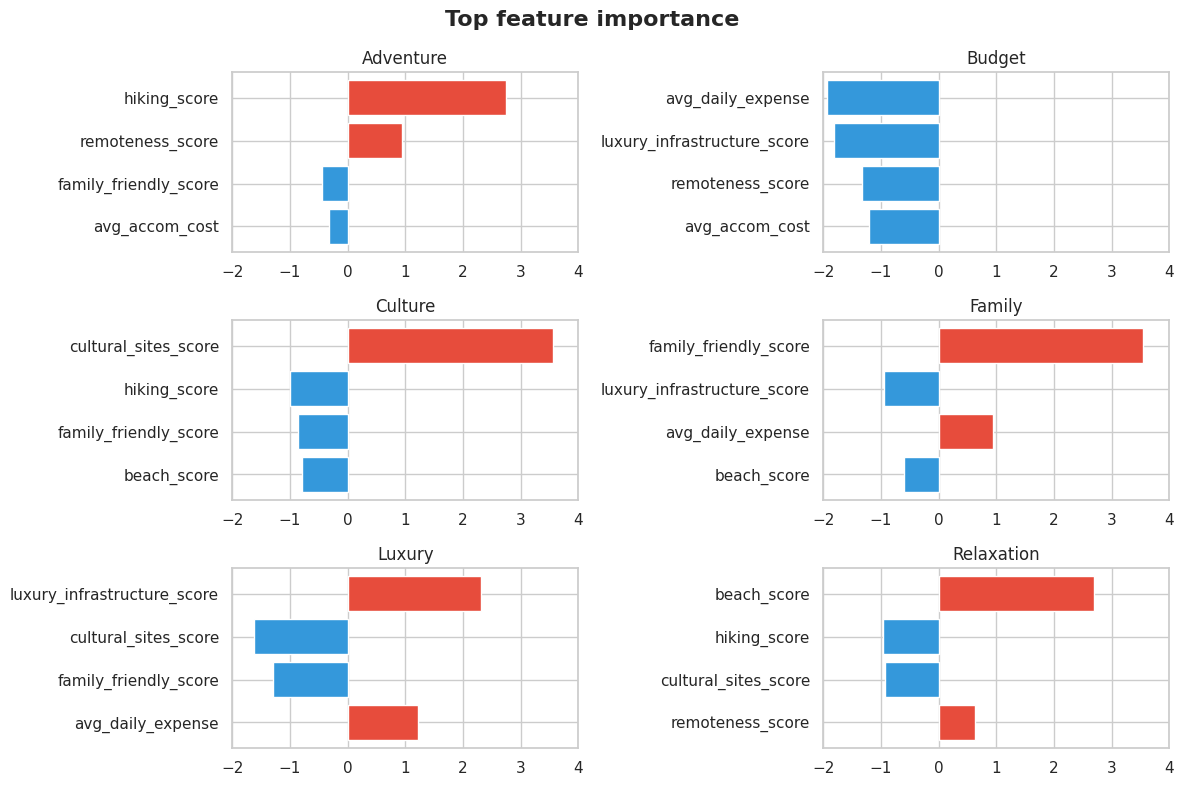

In [155]:
features = lr_pipeline['scaler'].get_feature_names_out()
label_names = lr_pipeline.named_steps['model'].classes_
coeffs_arr = lr_pipeline.named_steps['model'].coef_.tolist()

imp = { }
for label, coeffs in zip(label_names, coeffs_arr):
  # Map the relevant coefficents vector to the features list
  imp_df = pd.DataFrame({'feature': features, 'coefficient': coeffs})
  imp[label] = (imp_df.assign(abs_coef=lambda x: x['coefficient'].abs())
                      .sort_values('abs_coef', ascending=False)
                      .reset_index(drop=True))

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for ax, label in zip(axes.flatten(), label_names):
  top = imp[label].head(4)
  colors = [ '#e74c3c' if c > 0 else '#3498db' for c in top['coefficient'] ]
  ax.barh(top['feature'][::-1], top['coefficient'][::-1],
          color=colors[::-1], edgecolor='white')
  ax.set_title(label)
  ax.set_xlim(-2, 4)

plt.suptitle("Top feature importances", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()



### Baseline record

In [172]:
y_pred = lr_pipeline.predict(X_val)
y_prob = lr_pipeline.predict_proba(X_val)

# Recompute all val metrics cleanly for the baseline record
f1_val   = f1_score(y_val, y_pred, average='macro')
prec_val = precision_score(y_val, y_pred, average='macro')
rec_val  = recall_score(y_val, y_pred, average='macro')
auc_val  = roc_auc_score(y_val, y_prob, multi_class='ovr', average='macro')
ap_val   = average_precision_score(y_val, y_prob, average='macro')

auc_tr   = roc_auc_score(y_train, lr_pipeline.predict_proba(X_train),
                         multi_class='ovr', average='macro')
gap      = auc_tr - auc_val

print("=" * 62)
print("  LOGISTIC REGRESSION")
print("=" * 62)
print(f"  class_weight    : 'balanced'")
print(f"  max_iter        : 100")
print(f"  random_state    : 42")
print(f"  Split           : 60 / 20 / 20  (stratified)")
print("-" * 62)
print(f"  ## Macro scores ##")
print(f"  Val F1          : {f1_val:.4f}")
print(f"  Val AUC         : {auc_val:.4f}")
print(f"  Val Precision   : {prec_val:.4f}")
print(f"  Val Recall      : {rec_val:.4f}")
print(f"  Val PR-AUC      : {ap_val:.4f}")
print(f"  Train-Val Gap   : {gap:.4f}")

  LOGISTIC REGRESSION
  class_weight    : 'balanced'
  max_iter        : 100
  random_state    : 42
  Split           : 60 / 20 / 20  (stratified)
--------------------------------------------------------------
  ## Macro scores ##
  Val F1          : 0.8924
  Val AUC         : 0.9939
  Val Precision   : 0.8910
  Val Recall      : 0.8949
  Val PR-AUC      : 0.9718
  Train-Val Gap   : 0.0004


### Save model

In [174]:
import joblib

In [175]:
joblib.dump(lr_pipeline, "classifier.joblib")

['classifier.joblib']